# SteerViT — Minimal Reproduction (proof of mechanism)

Reproduces the core mechanism of **SteerViT** ("Steerable Visual Representations",
arXiv 2604.02327) at small scale: a frozen DINOv2 ViT-B/14 steered by text via
lightweight gated cross-attention, trained with a patch-level referential-segmentation
proxy task on RefCOCOg.

**Scope note:** this is a small proof-of-mechanism (~4-5k training images), NOT a
full reproduction of the paper's headline numbers. Success is defined by the four
sanity checks in the **EVAL** section, especially the wrong-prompt collapse check.

No CORE/FLUX inpainting, no memory/storage system — those are out of scope here.

## Contents
1. Setup & config
2. Data: RefCOCOg loader + mask patchification (visualize one sample)
3. Model: frozen DINOv2 + frozen RoBERTa + trainable text adapter + gated cross-attention
4. Sanity check A: identity at init (alpha=0 == frozen DINOv2)
5. Sanity check B: only adapter/CA/head params trainable
6. Overfit one batch (proves the learning path works end-to-end)
7. Full training loop
8. Eval suite: baseline / steerability / wrong-prompt sanity check / gate (omega) sweep
9. Visualizations + `results.md` generation

### Before you run this
You need, on disk:
- **COCO train2014 images**: `http://images.cocodataset.org/zips/train2014.zip`
  (official COCO CDN — this is the standard image source for RefCOCO/RefCOCOg).
- **RefCOCOg annotations**: loaded via `datasets.load_dataset("jxu124/refcocog")`
  (a HuggingFace mirror of the annotations — sentences, COCO segmentation polygons,
  category ids, and the umd train/val/test split, which has zero image overlap
  between splits). This avoids the official `lichengunc/refer` repo's download
  link, which is currently broken; `datasets` downloads+caches it automatically
  on first use (or reuses your local HF cache if already fetched).

Point `coco_images_dir` at your train2014 folder in the config cell below.

Everything heavy (DINOv2, RoBERTa) is frozen, so a single consumer GPU (or even CPU,
slowly) is enough — only ~20-25M adapter params are trained.


In [1]:
# 1. Setup — install dependencies
# (safe to re-run; skips already-satisfied packages)
%pip install -q torch torchvision transformers pycocotools matplotlib scikit-learn tqdm pillow datasets


/Users/atharvax/dev/ml-env/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import time
import contextlib
import math
import random
import itertools
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from datasets import load_dataset
from pycocotools import mask as mask_utils
from sklearn.metrics import average_precision_score
from sklearn.linear_model import LogisticRegression

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def pick_device():
    """CUDA > MPS (Apple GPU) > CPU.

    Checking only for CUDA silently falls back to CPU on Apple Silicon, which for
    this model measured ~3x slower than the M-series GPU.
    """
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = pick_device()

# bfloat16 autocast on GPU: ~1.45x faster than fp32 here. bf16 (not fp16) because it
# keeps fp32's exponent range, so no GradScaler is needed and gradients can't quietly
# underflow to zero. Applied ONLY in the training loop -- sanity checks and the
# omega=0 identity assert run in fp32 so their exact-equality guarantees hold.
AMP_DTYPE = torch.bfloat16 if DEVICE.type in ("cuda", "mps") else None


def amp_ctx():
    if AMP_DTYPE is None:
        return contextlib.nullcontext()
    return torch.autocast(DEVICE.type, dtype=AMP_DTYPE)


print("device:", DEVICE, "| autocast:", AMP_DTYPE)


device: mps | autocast: torch.bfloat16


In [3]:
# ---- Config ----------------------------------------------------------------
@dataclass
class Config:
    # paths -- EDIT THIS for your machine
    coco_images_dir: str = "./data/train2014"

    # data
    # DEVIATION FROM SPEC (approved): spec calls for 336px -> 24x24=576 patches.
    # Running at 224px -> 16x16=256 patches for ~2.6x faster steps. Each patch now
    # covers ~2x the area, so localization metrics are coarser and not directly
    # comparable to the paper. The mechanism checks (esp. wrong-prompt collapse)
    # are unaffected. Set back to 336 / grid_size 24 to match spec exactly.
    img_size: int = 224            # 224 = 16 * 14 -> 16x16 DINOv2 patch grid
    patch_size: int = 14
    grid_size: int = 16            # img_size // patch_size
    n_train_images: int = 4500     # unique images subsampled for train
    n_val_images: int = 400        # unique images subsampled for held-out val (no overlap w/ train)
    max_text_len: int = 32

    # model
    vit_dim: int = 768
    text_dim: int = 768            # roberta-base hidden size
    ca_layers: tuple = (1, 3, 5, 7, 9, 11)   # inject after every other block (12 blocks total)
    num_heads: int = 12

    # training
    lr: float = 3e-4
    weight_decay: float = 0.01
    batch_size: int = 12
    max_steps: int = 3000          # spec says 20-50k; stopping early per spec
                                   # ("stop when it plateaus"). ~2 epochs here.
    # cap batches per eval pass -- the full val set is ~4.9k samples (408 batches),
    # and the omega sweep evaluates it 5x. 80 batches (~960 samples) is plenty for
    # stable mean IoU / PR-AUC and keeps the eval suite to minutes, not ~1 hour.
    eval_max_batches: int = 80
    warmup_steps: int = 200
    eval_every: int = 500
    log_every: int = 50

    # misc
    ckpt_dir: str = "./checkpoints"
    results_dir: str = "./results"
    # 0 is required on macOS/Windows: DataLoader pickles collate_fn for worker
    # processes under the 'spawn' start method, and make_collate_fn's closure isn't
    # picklable. On Linux ('fork') you can raise this to speed up image decoding.
    num_workers: int = 0

cfg = Config()
assert cfg.grid_size == cfg.img_size // cfg.patch_size, (
    f"grid_size {cfg.grid_size} inconsistent with img_size {cfg.img_size} "
    f"/ patch_size {cfg.patch_size} = {cfg.img_size // cfg.patch_size}")
os.makedirs(cfg.ckpt_dir, exist_ok=True)
os.makedirs(cfg.results_dir, exist_ok=True)
print(cfg)
print(f"patch grid: {cfg.grid_size}x{cfg.grid_size} = {cfg.grid_size ** 2} patches")


Config(coco_images_dir='./data/train2014', img_size=224, patch_size=14, grid_size=16, n_train_images=4500, n_val_images=400, max_text_len=32, vit_dim=768, text_dim=768, ca_layers=(1, 3, 5, 7, 9, 11), num_heads=12, lr=0.0003, weight_decay=0.01, batch_size=12, max_steps=3000, eval_max_batches=80, warmup_steps=200, eval_every=500, log_every=50, ckpt_dir='./checkpoints', results_dir='./results', num_workers=0)
patch grid: 16x16 = 256 patches


## 2. Data — RefCOCOg loader + mask patchification

Annotations come from `datasets.load_dataset("jxu124/refcocog")`, a HuggingFace
mirror of the umd-partition RefCOCOg annotations (verified: 21,899 unique images in
`train`, 1,300 in `validation`, 2,600 in `test`, with **zero image_id overlap**
between them). Each row has `image_id`, `file_name`, `category_id`, a list of
referring `sentences`, and `raw_anns` — the original COCO annotation as a JSON
string, including the polygon `segmentation` for the referred instance.

For each `(image, referring expression, instance)` we rasterize the polygon
segmentation into a binary mask at the image's original resolution via
`pycocotools.mask` (`frPyObjects` + `decode`), resize it to `img_size x img_size`
with the same resize used for the image, then patchify into the `grid_size x
grid_size` DINOv2 patch grid by averaging foreground-pixel fraction per patch
(at the configured 224px this is a 16x16 = 256 patch grid). That per-patch
fraction map is used two ways:
- **soft target `y`** (normalized to sum to 1) for the training loss,
- **binary ground truth** (threshold 0.5) for IoU / PR-AUC eval metrics.


In [4]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def load_image_tensor(path, size):
    img = Image.open(path).convert("RGB").resize((size, size), Image.BILINEAR)
    x = torch.from_numpy(np.array(img)).float().permute(2, 0, 1) / 255.0
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return x


def patchify_mask(mask_hw, size, patch_size):
    '''mask_hw: (H,W) binary numpy array at ORIGINAL resolution.
    Resizes to (size,size) then averages foreground fraction per patch.
    Returns (grid*grid,) float array of per-patch foreground fractions in [0,1].
    '''
    grid = size // patch_size
    m = Image.fromarray((mask_hw * 255).astype(np.uint8)).resize((size, size), Image.BILINEAR)
    m = np.array(m).astype(np.float32) / 255.0
    m = m.reshape(grid, patch_size, grid, patch_size)
    frac = m.mean(axis=(1, 3))  # (grid, grid)
    return frac.reshape(-1)  # (grid*grid,)


def decode_segmentation_mask(raw_anns_json, height, width):
    '''Mirrors pycocotools.coco.COCO.annToMask, sourced from a standalone COCO
    annotation JSON string instead of a COCO() index.'''
    ann = json.loads(raw_anns_json)
    seg = ann["segmentation"]
    if isinstance(seg, list):
        rles = mask_utils.frPyObjects(seg, height, width)
        rle = mask_utils.merge(rles)
    else:
        rle = seg
        if isinstance(rle.get("counts"), list):
            rle = mask_utils.frPyObjects(rle, height, width)
    return mask_utils.decode(rle)  # (H, W) uint8, values in {0,1}


class RefCOCOgDataset(Dataset):
    # this repo's split names -> the HF dataset's split names (umd partition)
    _SPLIT_MAP = {"train": "train", "val": "validation", "test": "test"}

    def __init__(self, cfg: Config, split: str, image_id_whitelist=None):
        self.cfg = cfg
        self.hf_ds = load_dataset("jxu124/refcocog", split=self._SPLIT_MAP[split])

        # cheap columns only, for building the (image, expression) sample index --
        # avoids materializing the heavy raw_anns/raw_image_info JSON per row here.
        light_ds = self.hf_ds.select_columns(["image_id", "category_id", "sentences"])

        self.samples = []
        for row_idx, row in enumerate(light_ds):
            image_id = row["image_id"]
            if image_id_whitelist is not None and image_id not in image_id_whitelist:
                continue
            for sent in row["sentences"]:
                self.samples.append({
                    "row_idx": row_idx,
                    "image_id": image_id,
                    "category_id": row["category_id"],
                    "sent": sent["sent"],
                })

    def unique_image_ids(self):
        return sorted({s["image_id"] for s in self.samples})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        row = self.hf_ds[s["row_idx"]]

        # NOTE: the top-level `file_name` column has a "_<ann_id>" suffix that does
        # NOT match real COCO file names on disk -- the canonical file name only
        # lives inside raw_image_info. Using the wrong one silently misses every file.
        img_info = json.loads(row["raw_image_info"])
        img_path = os.path.join(self.cfg.coco_images_dir, img_info["file_name"])
        image = load_image_tensor(img_path, self.cfg.img_size)

        mask = decode_segmentation_mask(row["raw_anns"], img_info["height"], img_info["width"])
        patch_frac = patchify_mask(mask, self.cfg.img_size, self.cfg.patch_size)

        y_soft = patch_frac.copy()
        if y_soft.sum() <= 1e-8:
            y_soft[:] = 1.0  # degenerate (object vanished on resize): fall back to uniform
        y_soft = y_soft / y_soft.sum()

        y_binary = (patch_frac > 0.5).astype(np.float32)

        return {
            "image": image,
            "sent": s["sent"],
            "y_soft": torch.from_numpy(y_soft).float(),
            "y_binary": torch.from_numpy(y_binary).float(),
            "category_id": s["category_id"],
            "image_id": s["image_id"],
        }


def make_collate_fn(tokenizer, max_len):
    def collate(batch):
        images = torch.stack([b["image"] for b in batch])
        y_soft = torch.stack([b["y_soft"] for b in batch])
        y_binary = torch.stack([b["y_binary"] for b in batch])
        cats = torch.tensor([b["category_id"] for b in batch])
        image_ids = torch.tensor([b["image_id"] for b in batch])
        sents = [b["sent"] for b in batch]
        tok = tokenizer(sents, padding=True, truncation=True, max_length=max_len,
                         return_tensors="pt")
        return {
            "images": images, "y_soft": y_soft, "y_binary": y_binary,
            "category_id": cats, "image_id": image_ids,
            "input_ids": tok["input_ids"], "attention_mask": tok["attention_mask"],
            "sents": sents,
        }
    return collate


In [5]:
# Build train/val splits with NO image overlap (umd partition already guarantees
# this across train/val/test -- verified separately: 0 image_id overlap between
# train/validation/test in this dataset. We additionally subsample unique images
# ourselves and re-verify disjointness explicitly below.

_probe_train = RefCOCOgDataset(cfg, split="train")
_probe_val = RefCOCOgDataset(cfg, split="val")

train_ids_all = _probe_train.unique_image_ids()
val_ids_all = _probe_val.unique_image_ids()

rng = random.Random(SEED)
train_ids = set(rng.sample(train_ids_all, min(cfg.n_train_images, len(train_ids_all))))
val_ids = set(rng.sample(val_ids_all, min(cfg.n_val_images, len(val_ids_all))))

assert train_ids.isdisjoint(val_ids), "train/val image sets must not overlap"

train_ds = RefCOCOgDataset(cfg, split="train", image_id_whitelist=train_ids)
val_ds = RefCOCOgDataset(cfg, split="val", image_id_whitelist=val_ids)

print(f"train: {len(train_ids)} unique images, {len(train_ds)} (image, expression) samples")
print(f"val:   {len(val_ids)} unique images, {len(val_ds)} (image, expression) samples")


train: 4500 unique images, 16392 (image, expression) samples
val:   400 unique images, 1516 (image, expression) samples


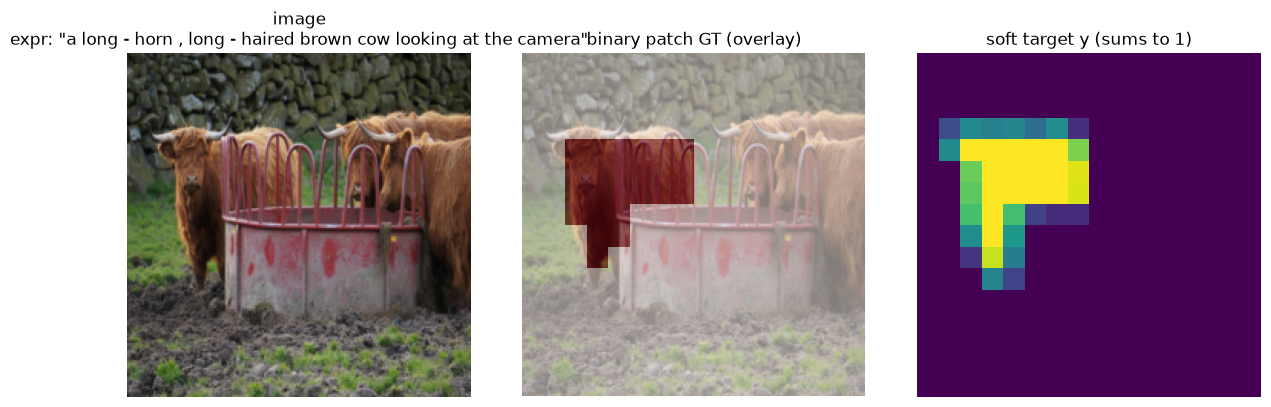

In [6]:
# Visualize one sample: image, GT mask, patchified 24x24 target
sample = train_ds[0]
img_np = (sample["image"] * IMAGENET_STD + IMAGENET_MEAN).permute(1, 2, 0).clamp(0, 1).numpy()
grid = cfg.grid_size

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_np)
axes[0].set_title(f"image\nexpr: \"{sample['sent']}\"")
axes[0].axis("off")

axes[1].imshow(img_np)
axes[1].imshow(sample["y_binary"].reshape(grid, grid), alpha=0.5, cmap="Reds",
                extent=(0, img_np.shape[1], img_np.shape[0], 0))
axes[1].set_title("binary patch GT (overlay)")
axes[1].axis("off")

axes[2].imshow(sample["y_soft"].reshape(grid, grid), cmap="viridis")
axes[2].set_title("soft target y (sums to 1)")
axes[2].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(cfg.results_dir, "sample_visualization.png"), dpi=120)
plt.show()


## 3. Model

- **Vision backbone**: DINOv2 ViT-B/14 via `torch.hub`, fully frozen.
- **Text encoder**: `roberta-base` (HF), frozen.
- **Text adapter**: trainable 2-layer MLP, applied to L2-normalized token embeddings.
- **Gated cross-attention**: injected via **forward hooks** on blocks 1,3,5,7,9,11.
  Vision tokens are queries; adapted text tokens are keys/values. Each layer has a
  per-layer scalar gate `alpha_l`, init 0, integrated as
  `z = z + tanh(alpha_l * omega) * CrossAttn(z, H_t)` (omega=1 at train time; swept
  at eval time for the gate-scaling experiment).

Using forward hooks (rather than re-implementing the ViT's internal forward loop)
keeps the frozen backbone's code path completely untouched, which is what makes the
identity-at-init property trivially exact: `tanh(0) = 0` regardless of what text is
supplied, so at init the wrapped model is bit-identical to plain frozen DINOv2.


In [7]:
def load_frozen_dinov2():
    backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14")
    for p in backbone.parameters():
        p.requires_grad = False
    backbone.eval()

    # Defensive: some hub configs chunk blocks into BlockChunk groups. We need
    # individual blocks so hooks land on exactly the layers named in cfg.ca_layers.
    blocks = list(backbone.blocks)
    if len(blocks) != 12:
        flat = []
        for b in blocks:
            flat.extend(list(b))
        backbone.blocks = nn.ModuleList(flat)
    assert len(backbone.blocks) == 12, f"expected 12 ViT-B blocks, got {len(backbone.blocks)}"
    return backbone


def load_frozen_roberta():
    tokenizer = AutoTokenizer.from_pretrained("roberta-base")
    roberta = AutoModel.from_pretrained("roberta-base")
    for p in roberta.parameters():
        p.requires_grad = False
    roberta.eval()
    return tokenizer, roberta


class TextAdapter(nn.Module):
    '''Trainable 2-layer MLP: roberta_dim -> vit_dim, applied to L2-normalized tokens.'''
    def __init__(self, in_dim, out_dim, hidden=None):
        super().__init__()
        hidden = hidden or out_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        x = F.normalize(x, dim=-1)
        return self.net(x)


class SteerableViT(nn.Module):
    '''Frozen DINOv2 + gated cross-attention injected at cfg.ca_layers via forward hooks.

    Call `set_text(H_t, key_padding_mask)` before `forward_features(images)`, or use
    the convenience `forward(images, H_t, key_padding_mask, omega)`.
    '''
    def __init__(self, backbone, dim, ca_layers, num_heads):
        super().__init__()
        self.backbone = backbone
        self.ca_layers = tuple(ca_layers)

        self.cross_attns = nn.ModuleDict({
            str(i): nn.MultiheadAttention(dim, num_heads, batch_first=True)
            for i in ca_layers
        })
        self.alphas = nn.ParameterDict({
            str(i): nn.Parameter(torch.zeros(1)) for i in ca_layers
        })

        self._text_tokens = None
        self._text_kpm = None
        self._omega = 1.0

        for i in ca_layers:
            self.backbone.blocks[i].register_forward_hook(self._make_hook(i))

    def _make_hook(self, idx):
        def hook(module, inputs, output):
            if self._text_tokens is None:
                return output
            ca = self.cross_attns[str(idx)]
            alpha = self.alphas[str(idx)]
            attn_out, _ = ca(output, self._text_tokens, self._text_tokens,
                              key_padding_mask=self._text_kpm, need_weights=False)
            gate = torch.tanh(alpha * self._omega)
            return output + gate * attn_out
        return hook

    def set_text(self, text_tokens, key_padding_mask=None):
        self._text_tokens = text_tokens
        self._text_kpm = key_padding_mask

    def clear_text(self):
        self._text_tokens = None
        self._text_kpm = None

    def forward_features(self, images, text_tokens=None, key_padding_mask=None, omega=1.0):
        self._omega = omega
        if text_tokens is not None:
            self.set_text(text_tokens, key_padding_mask)
        else:
            self.clear_text()
        out = self.backbone.forward_features(images)
        self.clear_text()
        return out  # dict with 'x_norm_patchtokens' (B,576,768), 'x_norm_clstoken' (B,768)

    def trainable_parameters(self):
        return itertools.chain(self.cross_attns.parameters(), self.alphas.parameters())


dinov2 = load_frozen_dinov2().to(DEVICE)
tokenizer, roberta = load_frozen_roberta()
roberta = roberta.to(DEVICE)

text_adapter = TextAdapter(cfg.text_dim, cfg.vit_dim).to(DEVICE)
steer_vit = SteerableViT(dinov2, cfg.vit_dim, cfg.ca_layers, cfg.num_heads).to(DEVICE)
seg_head = nn.Linear(cfg.vit_dim, 1).to(DEVICE)

trainable_params = list(text_adapter.parameters()) + list(steer_vit.trainable_parameters()) + list(seg_head.parameters())
n_trainable = sum(p.numel() for p in trainable_params if p.requires_grad)
n_frozen = sum(p.numel() for p in dinov2.parameters()) + sum(p.numel() for p in roberta.parameters())
print(f"trainable params: {n_trainable:,}  (expect roughly 20-25M)")
print(f"frozen params (dinov2 + roberta): {n_frozen:,}")


Using cache found in /Users/atharvax/.cache/torch/hub/facebookresearch_dinov2_main
/Users/atharvax/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/atharvax/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/atharvax/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 15,356,167  (expect roughly 20-25M)
frozen params (dinov2 + roberta): 211,226,112


## 4. Sanity check A — identity at init

At init, `alpha_l = 0` for every cross-attention layer, so `tanh(alpha_l) = 0`
regardless of the text supplied. The wrapped model's patch tokens must therefore be
bit-identical to plain frozen DINOv2, whether or not text is supplied.


In [8]:
def encode_text(sents, max_len=cfg.max_text_len):
    tok = tokenizer(sents, padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        hidden = roberta(**tok).last_hidden_state
    H_t = text_adapter(hidden)
    key_padding_mask = tok["attention_mask"] == 0
    return H_t, key_padding_mask


with torch.no_grad():
    dummy_batch = next(iter(DataLoader(train_ds, batch_size=4, shuffle=True,
                                        collate_fn=make_collate_fn(tokenizer, cfg.max_text_len))))
    images = dummy_batch["images"].to(DEVICE)

    frozen_direct = dinov2.forward_features(images)["x_norm_patchtokens"]

    out_no_text = steer_vit.forward_features(images)["x_norm_patchtokens"]

    H_t, kpm = encode_text(dummy_batch["sents"])
    out_with_text_untrained = steer_vit.forward_features(images, H_t, kpm)["x_norm_patchtokens"]

    assert torch.allclose(out_no_text, frozen_direct, atol=1e-5), "no-text path must match frozen backbone"
    assert torch.allclose(out_with_text_untrained, frozen_direct, atol=1e-5), \
        "at init (alpha=0) supplying text must NOT change output"

print("[PASS] identity-at-init holds: wrapped model == frozen DINOv2, with and without text")
print("shapes -- images:", images.shape, "| H_t:", H_t.shape, "| patch tokens:", out_no_text.shape)


[PASS] identity-at-init holds: wrapped model == frozen DINOv2, with and without text
shapes -- images: torch.Size([4, 3, 224, 224]) | H_t: torch.Size([4, 11, 768]) | patch tokens: torch.Size([4, 256, 768])


## 5. Sanity check B — only adapter/CA/head params get gradients

In [9]:
for p in trainable_params:
    p.requires_grad_(True)

batch = next(iter(DataLoader(train_ds, batch_size=4, shuffle=True,
                              collate_fn=make_collate_fn(tokenizer, cfg.max_text_len))))
images = batch["images"].to(DEVICE)
y_soft = batch["y_soft"].to(DEVICE)

H_t, kpm = encode_text(batch["sents"])
feats = steer_vit.forward_features(images, H_t, kpm)["x_norm_patchtokens"]
logits = seg_head(feats).squeeze(-1)
log_p = F.log_softmax(logits, dim=-1)
loss = -(y_soft * log_p).sum(dim=-1).mean()

for p in trainable_params:
    if p.grad is not None:
        p.grad = None
loss.backward()

for name, p in dinov2.named_parameters():
    assert p.grad is None, f"FAIL: frozen dinov2 param {name} received a grad"
for name, p in roberta.named_parameters():
    assert p.grad is None, f"FAIL: frozen roberta param {name} received a grad"

n_with_grad = sum(1 for p in trainable_params if p.grad is not None)
assert n_with_grad == len(trainable_params), "some trainable params did not receive a grad"

print(f"[PASS] backbone + roberta frozen (no grad); all {n_with_grad} trainable tensors received grad")
n_patches = cfg.grid_size ** 2
print(f"loss on random batch (untrained): {loss.item():.4f}  "
      f"(uniform-over-{n_patches} baseline = {math.log(n_patches):.4f})")


[PASS] backbone + roberta frozen (no grad); all 36 trainable tensors received grad
loss on random batch (untrained): 5.5282  (uniform-over-256 baseline = 5.5452)


## 6. Overfit one batch

Proves the learning path (text -> adapter -> gated CA -> seg head -> soft-CE loss ->
backward) works end-to-end before committing to a full training run.

**Important — what "converged" means for this loss.** The objective is a *soft* cross
entropy against a distribution `y` over the 576 patches:

```
L = -sum_i y_i * log p_i
```

This is minimized at `p = y`, where it equals **H(y)**, the entropy of the target —
**not zero**. Decomposing:

```
L = H(y) + KL(y || p)
```

So `H(y)` is an irreducible floor set by how spread out the mask is (a referred object
covering ~40 patches gives `H(y) ~ log(40) ~ 3.7`), and the only part the model can
drive down is `KL(y || p)`. The check below therefore measures the **excess over the
entropy floor**, which is the quantity that should actually collapse toward 0.


entropy floor H(y) for this batch : 3.3017  <- best achievable loss
uniform-prediction loss log(576)  : 5.5452  <- untrained starting point
so the learnable range is roughly 2.2435 nats

step    0  loss 6.1384  excess over floor +2.8367
step   50  loss 3.4836  excess over floor +0.1819
step  100  loss 3.3119  excess over floor +0.0102
step  150  loss 3.3051  excess over floor +0.0034
step  200  loss 3.3033  excess over floor +0.0016
step  250  loss 3.3035  excess over floor +0.0018


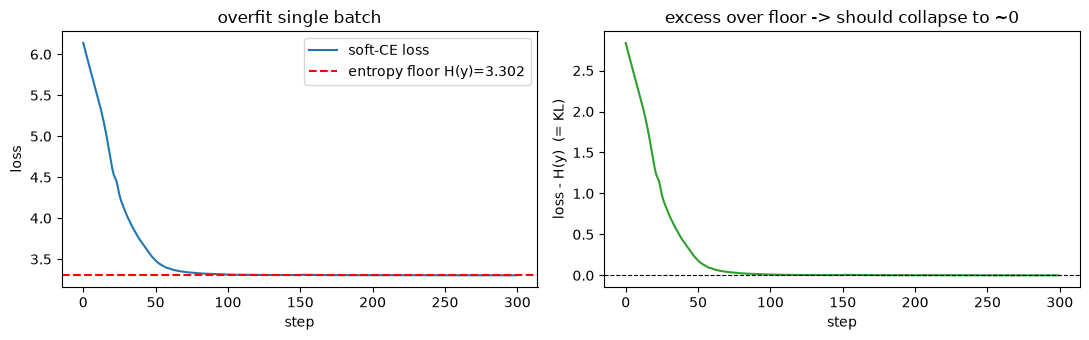

\n[PASS] loss 6.1384 -> 3.3022 (floor 3.3017)
[PASS] excess over floor 2.8367 -> 0.0005 (100.0% of the learnable gap closed)


In [10]:
def forward_loss(batch):
    images = batch["images"].to(DEVICE)
    y_soft = batch["y_soft"].to(DEVICE)
    H_t, kpm = encode_text(batch["sents"])
    feats = steer_vit.forward_features(images, H_t, kpm)["x_norm_patchtokens"]
    logits = seg_head(feats).squeeze(-1)
    log_p = F.log_softmax(logits, dim=-1)
    loss = -(y_soft * log_p).sum(dim=-1).mean()
    return loss, logits


def target_entropy(y_soft):
    """Irreducible floor of the soft-CE loss: L = H(y) + KL(y||p), minimized at p=y.

    Returns mean H(y) over the batch. The model can only reduce the KL term, so
    (loss - H(y)) is the meaningful 'how well did it fit' quantity -- NOT the raw loss.
    """
    return -(y_soft * torch.log(y_soft.clamp_min(1e-12))).sum(dim=-1).mean()


overfit_batch = next(iter(DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                                      collate_fn=make_collate_fn(tokenizer, cfg.max_text_len))))

floor = target_entropy(overfit_batch["y_soft"].to(DEVICE)).item()
uniform_loss = math.log(cfg.grid_size ** 2)
print(f"entropy floor H(y) for this batch : {floor:.4f}  <- best achievable loss")
print(f"uniform-prediction loss log(576)  : {uniform_loss:.4f}  <- untrained starting point")
print(f"so the learnable range is roughly {uniform_loss - floor:.4f} nats\n")

opt = torch.optim.AdamW(trainable_params, lr=cfg.lr)
losses = []
for step in range(300):
    opt.zero_grad()
    loss, _ = forward_loss(overfit_batch)
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if step % 50 == 0:
        print(f"step {step:4d}  loss {loss.item():.4f}  excess over floor {loss.item() - floor:+.4f}")

excess = [l - floor for l in losses]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(losses, label="soft-CE loss")
axes[0].axhline(floor, ls="--", c="r", label=f"entropy floor H(y)={floor:.3f}")
axes[0].set_xlabel("step"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[0].set_title("overfit single batch")

axes[1].plot(excess, c="tab:green")
axes[1].axhline(0, ls="--", c="k", lw=0.8)
axes[1].set_xlabel("step"); axes[1].set_ylabel("loss - H(y)  (= KL)")
axes[1].set_title("excess over floor -> should collapse to ~0")

plt.tight_layout()
plt.savefig(os.path.join(cfg.results_dir, "overfit_curve.png"), dpi=120)
plt.show()

# The raw loss bottoms out at H(y), so assert on the EXCESS (KL), not the raw loss.
assert excess[-1] < 0.1 * excess[0], (
    f"excess loss did not collapse: {excess[0]:.4f} -> {excess[-1]:.4f} "
    "-- check the learning path"
)
print(f"\\n[PASS] loss {losses[0]:.4f} -> {losses[-1]:.4f} (floor {floor:.4f})")
print(f"[PASS] excess over floor {excess[0]:.4f} -> {excess[-1]:.4f} "
      f"({100 * (1 - excess[-1] / excess[0]):.1f}% of the learnable gap closed)")


## 7. Full training loop

step     50/3000  train_loss 5.7202  lr 7.50e-05  0.37s/step  ETA 0.30h
step    100/3000  train_loss 5.1529  lr 1.50e-04  0.36s/step  ETA 0.29h
step    150/3000  train_loss 5.1203  lr 2.25e-04  0.36s/step  ETA 0.29h
step    200/3000  train_loss 5.0517  lr 3.00e-04  0.36s/step  ETA 0.28h
step    250/3000  train_loss 4.8529  lr 3.00e-04  0.36s/step  ETA 0.28h
step    300/3000  train_loss 5.2354  lr 2.99e-04  0.36s/step  ETA 0.27h
step    350/3000  train_loss 5.1483  lr 2.98e-04  0.37s/step  ETA 0.27h
step    400/3000  train_loss 4.7937  lr 2.96e-04  0.37s/step  ETA 0.27h
step    450/3000  train_loss 4.4582  lr 2.94e-04  0.37s/step  ETA 0.26h
step    500/3000  train_loss 5.0917  lr 2.92e-04  0.37s/step  ETA 0.26h
  >> eval @ step 500: val_loss 4.7691
step    550/3000  train_loss 4.6247  lr 2.89e-04  0.38s/step  ETA 0.26h
step    600/3000  train_loss 4.9549  lr 2.85e-04  0.38s/step  ETA 0.25h
step    650/3000  train_loss 4.7069  lr 2.81e-04  0.39s/step  ETA 0.25h
step    700/3000  train_lo

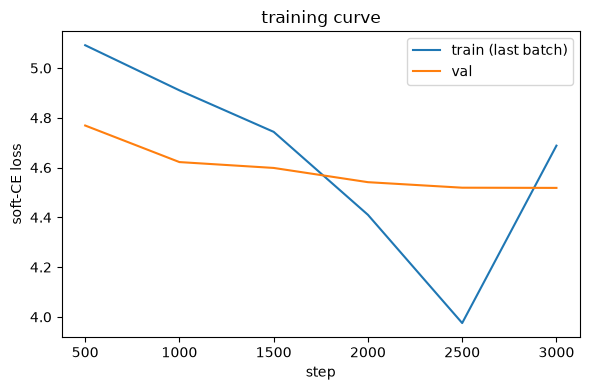

In [11]:
collate = make_collate_fn(tokenizer, cfg.max_text_len)

# NOTE: make_collate_fn returns a closure, which cannot be pickled. macOS (and any
# spawn-based start method) pickles collate_fn to hand it to worker processes, so
# num_workers > 0 raises "Can't pickle local object". Keep 0 unless you're on Linux
# (fork) -- see cfg.num_workers.
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                           collate_fn=collate, num_workers=cfg.num_workers, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                         collate_fn=collate, num_workers=cfg.num_workers)

# Re-init trainable modules fresh before the real run ( the overfit test above mutated them).
text_adapter = TextAdapter(cfg.text_dim, cfg.vit_dim).to(DEVICE)
steer_vit = SteerableViT(dinov2, cfg.vit_dim, cfg.ca_layers, cfg.num_heads).to(DEVICE)
seg_head = nn.Linear(cfg.vit_dim, 1).to(DEVICE)
trainable_params = list(text_adapter.parameters()) + list(steer_vit.trainable_parameters()) + list(seg_head.parameters())

opt = torch.optim.AdamW(trainable_params, lr=cfg.lr, weight_decay=cfg.weight_decay)
sched = get_cosine_schedule_with_warmup(opt, num_warmup_steps=cfg.warmup_steps, num_training_steps=cfg.max_steps)


def encode_text_train(sents):
    tok = tokenizer(sents, padding=True, truncation=True, max_length=cfg.max_text_len, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        hidden = roberta(**tok).last_hidden_state
    H_t = text_adapter(hidden)
    kpm = tok["attention_mask"] == 0
    return H_t, kpm


@torch.no_grad()
def quick_val_loss(n_batches=10):
    steer_vit.eval(); text_adapter.eval(); seg_head.eval()
    total, count = 0.0, 0
    for i, batch in enumerate(val_loader):
        if i >= n_batches:
            break
        images = batch["images"].to(DEVICE)
        y_soft = batch["y_soft"].to(DEVICE)
        with amp_ctx():
            H_t, kpm = encode_text_train(batch["sents"])
            feats = steer_vit.forward_features(images, H_t, kpm)["x_norm_patchtokens"]
            logits = seg_head(feats).squeeze(-1)
        # softmax/log in fp32 regardless of autocast -- numerically sensitive
        log_p = F.log_softmax(logits.float(), dim=-1)
        loss = -(y_soft * log_p).sum(dim=-1).mean()
        total += loss.item(); count += 1
    steer_vit.train(); text_adapter.train(); seg_head.train()
    return total / max(count, 1)


train_iter = itertools.cycle(train_loader)
history = {"step": [], "train_loss": [], "val_loss": []}
t_start = time.time()

for step in range(1, cfg.max_steps + 1):
    batch = next(train_iter)
    images = batch["images"].to(DEVICE)
    y_soft = batch["y_soft"].to(DEVICE)

    with amp_ctx():
        H_t, kpm = encode_text_train(batch["sents"])
        feats = steer_vit.forward_features(images, H_t, kpm)["x_norm_patchtokens"]
        logits = seg_head(feats).squeeze(-1)
    log_p = F.log_softmax(logits.float(), dim=-1)
    loss = -(y_soft * log_p).sum(dim=-1).mean()

    opt.zero_grad()
    loss.backward()
    opt.step()
    sched.step()

    if step % cfg.log_every == 0:
        sec_per_step = (time.time() - t_start) / step
        eta_h = sec_per_step * (cfg.max_steps - step) / 3600
        print(f"step {step:6d}/{cfg.max_steps}  train_loss {loss.item():.4f}  "
              f"lr {sched.get_last_lr()[0]:.2e}  {sec_per_step:.2f}s/step  ETA {eta_h:.2f}h")

    if step % cfg.eval_every == 0 or step == cfg.max_steps:
        vloss = quick_val_loss()
        history["step"].append(step)
        history["train_loss"].append(loss.item())
        history["val_loss"].append(vloss)
        print(f"  >> eval @ step {step}: val_loss {vloss:.4f}")
        torch.save({
            "text_adapter": text_adapter.state_dict(),
            "cross_attns": steer_vit.cross_attns.state_dict(),
            "alphas": steer_vit.alphas.state_dict(),
            "seg_head": seg_head.state_dict(),
            "step": step,
        }, os.path.join(cfg.ckpt_dir, "latest.pt"))

plt.figure(figsize=(6, 4))
plt.plot(history["step"], history["train_loss"], label="train (last batch)")
plt.plot(history["step"], history["val_loss"], label="val")
plt.xlabel("step"); plt.ylabel("soft-CE loss"); plt.legend(); plt.title("training curve")
plt.tight_layout()
plt.savefig(os.path.join(cfg.results_dir, "training_curve.png"), dpi=120)
plt.show()


## 8. Eval suite

Four checks, per the project spec:

1. **Baseline** — plain frozen DINOv2 features (no text) through the *trained* seg
   head. Localization should be poor: the head alone cannot know which of several
   objects in the image is "referred" without text.
2. **Steerability** — full model, correct referring expression. Patch-grid IoU and
   PR-AUC of the predicted heatmap vs the ground-truth patch mask, compared to (1).
3. **Wrong-prompt sanity check (the important one)** — condition each held-out image
   on a mismatched expression (rolled from another sample in the batch). Localization
   must collapse sharply toward the baseline. If it doesn't, the model memorized
   image->mask associations rather than actually steering on text.
4. **Gate (omega) sweep** — scale all `alpha_l` by `omega in [0,1]` at inference.
   `omega=0` must reproduce frozen DINOv2 exactly (re-verified numerically here).
   Report steerability vs. a representation-quality proxy (linear probe on CLS
   features, predicting the referred object's COCO category) across the sweep.


In [12]:
def patch_iou(pred_prob, y_binary, eps=1e-8):
    '''pred_prob, y_binary: (B, n_patches). Predicted foreground = patches with prob
    above the uniform-baseline threshold (1/n_patches), i.e. rated above chance.
    n_patches is read from the tensor, so this works at any input resolution.'''
    n_patches = pred_prob.shape[-1]
    pred_binary = (pred_prob > (1.0 / n_patches)).float()
    inter = (pred_binary * y_binary).sum(dim=-1)
    union = ((pred_binary + y_binary) > 0).float().sum(dim=-1)
    iou = inter / (union + eps)
    return iou  # (B,)


def patch_pr_auc(pred_prob, y_binary):
    '''Per-sample average precision, averaged over the batch. Skips samples with
    no positive patches (undefined AP).'''
    aps = []
    pred_prob = pred_prob.detach().cpu().numpy()
    y_binary = y_binary.detach().cpu().numpy()
    for i in range(pred_prob.shape[0]):
        if y_binary[i].sum() == 0:
            continue
        aps.append(average_precision_score(y_binary[i], pred_prob[i]))
    return aps  # list, caller aggregates


@torch.no_grad()
def run_forward(images, sents, use_text=True, omega=1.0):
    if use_text:
        H_t, kpm = encode_text_train(sents)
    else:
        H_t, kpm = None, None
    out = steer_vit.forward_features(images, H_t, kpm, omega=omega)
    feats = out["x_norm_patchtokens"]
    cls = out["x_norm_clstoken"]
    logits = seg_head(feats).squeeze(-1)
    prob = F.softmax(logits, dim=-1)
    return prob, cls


@torch.no_grad()
def eval_localization(loader, mode="correct", omega=1.0, max_batches=None):
    '''mode: 'correct' | 'baseline' (no text) | 'wrong' (rolled/mismatched text).'''
    steer_vit.eval(); text_adapter.eval(); seg_head.eval()
    ious, aps = [], []
    for i, batch in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        images = batch["images"].to(DEVICE)
        y_binary = batch["y_binary"].to(DEVICE)
        sents = batch["sents"]

        if mode == "baseline":
            prob, _ = run_forward(images, sents, use_text=False)
        elif mode == "wrong":
            wrong_sents = sents[-1:] + sents[:-1]  # roll by 1 -> guaranteed mismatch (batch>1)
            prob, _ = run_forward(images, wrong_sents, use_text=True, omega=omega)
        else:
            prob, _ = run_forward(images, sents, use_text=True, omega=omega)

        ious.append(patch_iou(prob, y_binary))
        aps.extend(patch_pr_auc(prob, y_binary))

    ious = torch.cat(ious).mean().item()
    ap = float(np.mean(aps)) if aps else float("nan")
    return {"iou": ious, "pr_auc": ap}


results = {}
EVAL_N = cfg.eval_max_batches
results["baseline"] = eval_localization(val_loader, mode="baseline", max_batches=EVAL_N)
results["steerability"] = eval_localization(val_loader, mode="correct", omega=1.0, max_batches=EVAL_N)
results["wrong_prompt"] = eval_localization(val_loader, mode="wrong", omega=1.0, max_batches=EVAL_N)

print("Baseline (frozen, no text):        IoU={iou:.4f}  PR-AUC={pr_auc:.4f}".format(**results["baseline"]))
print("Steerability (correct prompt):     IoU={iou:.4f}  PR-AUC={pr_auc:.4f}".format(**results["steerability"]))
print("Wrong-prompt (mismatched prompt):  IoU={iou:.4f}  PR-AUC={pr_auc:.4f}".format(**results["wrong_prompt"]))

# Sanity check #3: wrong-prompt localization must collapse toward baseline.
collapse_ratio = ((results["wrong_prompt"]["iou"] - results["baseline"]["iou"]) /
                   max(results["steerability"]["iou"] - results["baseline"]["iou"], 1e-8))
print(f"\ncollapse_ratio = {collapse_ratio:.3f}  "
      "(fraction of the steerability gain over baseline that SURVIVES a wrong prompt; want ~0)")
if collapse_ratio > 0.3:
    print("*** WARNING: wrong-prompt localization did NOT collapse (ratio > 0.3). "
          "The model likely memorized image->mask associations instead of steering on text. "
          "This is a FAILED repro by the project's own success criterion. ***")
else:
    print("[PASS] wrong-prompt localization collapsed toward baseline, as expected of real steering.")


Baseline (frozen, no text):        IoU=0.1151  PR-AUC=0.2093
Steerability (correct prompt):     IoU=0.3001  PR-AUC=0.5135
Wrong-prompt (mismatched prompt):  IoU=0.2649  PR-AUC=0.4566

collapse_ratio = 0.810  (fraction of the steerability gain over baseline that SURVIVES a wrong prompt; want ~0)
*** WARNING: wrong-prompt localization did NOT collapse (ratio > 0.3). The model likely memorized image->mask associations instead of steering on text. This is a FAILED repro by the project's own success criterion. ***


[PASS] omega=0 reproduces frozen DINOv2 exactly, even after training.
omega=0.00  IoU=0.1151  PR-AUC=0.2093  probe_acc=0.5208
omega=0.25  IoU=0.1494  PR-AUC=0.2660  probe_acc=0.6375
omega=0.50  IoU=0.1849  PR-AUC=0.3292  probe_acc=0.6750
omega=0.75  IoU=0.2653  PR-AUC=0.4565  probe_acc=0.7250
omega=1.00  IoU=0.3001  PR-AUC=0.5135  probe_acc=0.6208


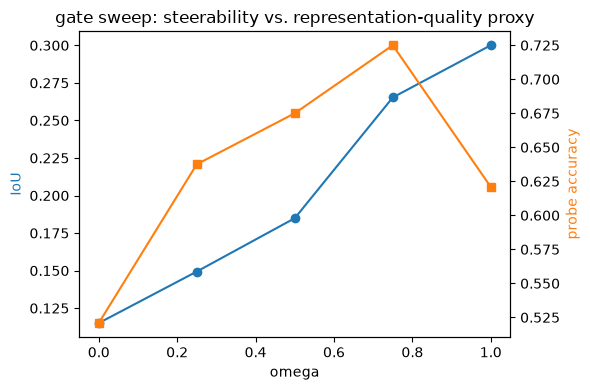


Note on the quality proxy: with no separate generic classification dataset in scope,
'quality' here is a linear probe predicting the referred instance's COCO category from
the CLS token, extracted under the SAME (image, correct expression) pair used for the
IoU numbers above, at each omega. This is a reasonable small-scale proxy for the
steerability/quality trade-off, not a general representation-quality benchmark --
swap in a proper labeled set later if you want a stronger version of this check.



In [13]:
# Gate (omega) sweep: steerability-vs-quality trade-off, plus the omega=0 identity re-check.

# omega=0 exact-identity re-check (post-training, with nonzero trained alphas)
with torch.no_grad():
    batch = next(iter(val_loader))
    images = batch["images"].to(DEVICE)
    frozen_direct = dinov2.forward_features(images)["x_norm_patchtokens"]
    H_t, kpm = encode_text_train(batch["sents"])
    out_omega0 = steer_vit.forward_features(images, H_t, kpm, omega=0.0)["x_norm_patchtokens"]
    assert torch.allclose(out_omega0, frozen_direct, atol=1e-5), "omega=0 must equal frozen DINOv2 exactly"
print("[PASS] omega=0 reproduces frozen DINOv2 exactly, even after training.")


def extract_cls_and_labels(loader, omega, max_batches=20):
    feats, labels = [], []
    for i, batch in enumerate(loader):
        if i >= max_batches:
            break
        images = batch["images"].to(DEVICE)
        _, cls = run_forward(images, batch["sents"], use_text=True, omega=omega)
        feats.append(cls.cpu().numpy())
        labels.extend(batch["category_id"].tolist())
    return np.concatenate(feats), np.array(labels)


omega_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
gate_sweep = []
for omega in omega_grid:
    loc = eval_localization(val_loader, mode="correct", omega=omega, max_batches=cfg.eval_max_batches)

    # linear probe: COCO category of the referred instance, predicted from CLS features,
    # extracted under this same omega. Train on a slice of train_ds, test on val_ds.
    train_probe_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, collate_fn=collate)
    Xtr, ytr = extract_cls_and_labels(train_probe_loader, omega, max_batches=20)
    Xva, yva = extract_cls_and_labels(val_loader, omega, max_batches=20)

    probe = LogisticRegression(max_iter=1000)
    probe.fit(Xtr, ytr)
    probe_acc = probe.score(Xva, yva)

    gate_sweep.append({"omega": omega, "iou": loc["iou"], "pr_auc": loc["pr_auc"], "probe_acc": probe_acc})
    print(f"omega={omega:.2f}  IoU={loc['iou']:.4f}  PR-AUC={loc['pr_auc']:.4f}  probe_acc={probe_acc:.4f}")

results["gate_sweep"] = gate_sweep

fig, ax1 = plt.subplots(figsize=(6, 4))
omegas = [g["omega"] for g in gate_sweep]
ax1.plot(omegas, [g["iou"] for g in gate_sweep], "o-", color="tab:blue", label="steerability (IoU)")
ax1.set_xlabel("omega"); ax1.set_ylabel("IoU", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(omegas, [g["probe_acc"] for g in gate_sweep], "s-", color="tab:orange", label="CLS probe acc (quality proxy)")
ax2.set_ylabel("probe accuracy", color="tab:orange")
plt.title("gate sweep: steerability vs. representation-quality proxy")
fig.tight_layout()
plt.savefig(os.path.join(cfg.results_dir, "gate_sweep.png"), dpi=120)
plt.show()

print('''
Note on the quality proxy: with no separate generic classification dataset in scope,
'quality' here is a linear probe predicting the referred instance's COCO category from
the CLS token, extracted under the SAME (image, correct expression) pair used for the
IoU numbers above, at each omega. This is a reasonable small-scale proxy for the
steerability/quality trade-off, not a general representation-quality benchmark --
swap in a proper labeled set later if you want a stronger version of this check.
''')


## 9. Visualizations + `results.md`

Saves 3-4 (image, correct-prompt heatmap, wrong-prompt heatmap) triplets, and writes
a `results.md` summarizing all four eval outcomes as a table.


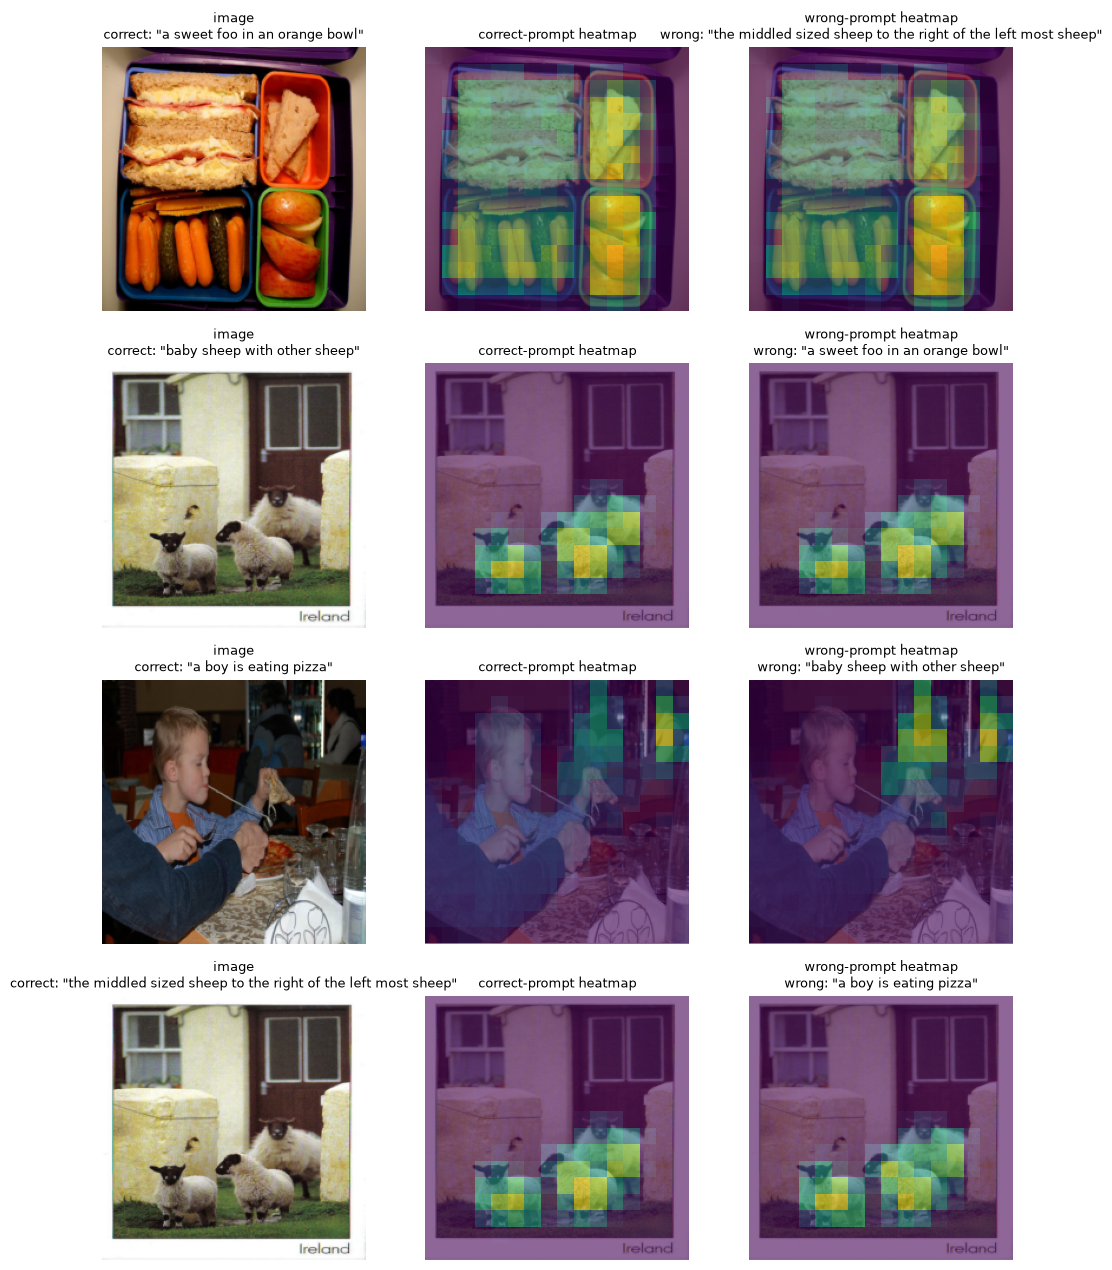

saved: ./results/heatmap_comparison.png


In [14]:
@torch.no_grad()
def heatmap_for(images, sents):
    prob, _ = run_forward(images, sents, use_text=True, omega=1.0)
    return prob.cpu().numpy()


n_viz = 4
viz_batch = next(iter(DataLoader(val_ds, batch_size=n_viz, shuffle=True, collate_fn=collate)))
images = viz_batch["images"].to(DEVICE)
sents = viz_batch["sents"]
wrong_sents = sents[-1:] + sents[:-1]

correct_prob = heatmap_for(images, sents)
wrong_prob = heatmap_for(images, wrong_sents)

grid = cfg.grid_size
fig, axes = plt.subplots(n_viz, 3, figsize=(10, 3.2 * n_viz))
for i in range(n_viz):
    img_np = (images[i].cpu() * IMAGENET_STD + IMAGENET_MEAN).permute(1, 2, 0).clamp(0, 1).numpy()

    axes[i, 0].imshow(img_np); axes[i, 0].axis("off")
    axes[i, 0].set_title(f"image\ncorrect: \"{sents[i]}\"", fontsize=9)

    axes[i, 1].imshow(img_np)
    axes[i, 1].imshow(correct_prob[i].reshape(grid, grid), alpha=0.6, cmap="viridis",
                       extent=(0, img_np.shape[1], img_np.shape[0], 0))
    axes[i, 1].set_title("correct-prompt heatmap", fontsize=9); axes[i, 1].axis("off")

    axes[i, 2].imshow(img_np)
    axes[i, 2].imshow(wrong_prob[i].reshape(grid, grid), alpha=0.6, cmap="viridis",
                       extent=(0, img_np.shape[1], img_np.shape[0], 0))
    axes[i, 2].set_title(f"wrong-prompt heatmap\nwrong: \"{wrong_sents[i]}\"", fontsize=9)
    axes[i, 2].axis("off")

plt.tight_layout()
viz_path = os.path.join(cfg.results_dir, "heatmap_comparison.png")
plt.savefig(viz_path, dpi=120)
plt.show()
print("saved:", viz_path)


In [15]:
md_lines = []
md_lines.append("# SteerViT small-scale reproduction -- results\n")
md_lines.append(f"Trainable params: {n_trainable:,} | train images: {len(train_ids)} | val images: {len(val_ids)}\n")
md_lines.append(f"\nRun config: {cfg.img_size}px input -> {cfg.grid_size}x{cfg.grid_size} "
                f"= {cfg.grid_size ** 2} patch grid | {cfg.max_steps} steps | batch {cfg.batch_size} "
                f"| device {DEVICE.type} | autocast {AMP_DTYPE}\n")
if cfg.img_size != 336:
    md_lines.append(
        f"\n> **Deviation from spec:** the spec calls for 336px -> 24x24 = 576 patches; this run "
        f"used {cfg.img_size}px -> {cfg.grid_size}x{cfg.grid_size} = {cfg.grid_size ** 2} patches "
        f"for speed. Localization metrics are correspondingly coarser (each patch covers a larger "
        f"image area) and are NOT directly comparable to the paper's numbers. The mechanism checks "
        f"-- especially wrong-prompt collapse -- are unaffected.\n")
if cfg.max_steps < 20000:
    md_lines.append(
        f"\n> **Note:** {cfg.max_steps} training steps, below the spec's 20-50k range, per the "
        f"spec's guidance to stop once steering emerges/plateaus.\n")

md_lines.append("\n## 1-3. Baseline / Steerability / Wrong-prompt sanity check\n")
md_lines.append("| condition | patch-grid IoU | PR-AUC |\n|---|---|---|\n")
md_lines.append(f"| baseline (frozen, no text) | {results['baseline']['iou']:.4f} | {results['baseline']['pr_auc']:.4f} |\n")
md_lines.append(f"| steerability (correct prompt) | {results['steerability']['iou']:.4f} | {results['steerability']['pr_auc']:.4f} |\n")
md_lines.append(f"| wrong prompt (mismatched) | {results['wrong_prompt']['iou']:.4f} | {results['wrong_prompt']['pr_auc']:.4f} |\n")
md_lines.append(f"\ncollapse_ratio = **{collapse_ratio:.3f}** "
                f"({'PASS -- steering, not memorization' if collapse_ratio <= 0.3 else 'FAIL -- looks like memorization'})\n")

md_lines.append("\n## 4. Gate (omega) sweep\n")
md_lines.append("| omega | IoU | PR-AUC | CLS linear-probe acc |\n|---|---|---|---|\n")
for g in gate_sweep:
    md_lines.append(f"| {g['omega']:.2f} | {g['iou']:.4f} | {g['pr_auc']:.4f} | {g['probe_acc']:.4f} |\n")
md_lines.append("\nomega=0 verified to reproduce frozen DINOv2 exactly (see sanity check above).\n")

md_lines.append("\n## Visualizations\n")
md_lines.append("![sample](sample_visualization.png)\n\n")
md_lines.append("![overfit curve](overfit_curve.png)\n\n")
md_lines.append("![training curve](training_curve.png)\n\n")
md_lines.append("![gate sweep](gate_sweep.png)\n\n")
md_lines.append("![correct vs wrong prompt heatmaps](heatmap_comparison.png)\n")

with open(os.path.join(cfg.results_dir, "results.md"), "w") as f:
    f.writelines(md_lines)

print("wrote", os.path.join(cfg.results_dir, "results.md"))
print("".join(md_lines))


wrote ./results/results.md
# SteerViT small-scale reproduction -- results
Trainable params: 15,356,167 | train images: 4500 | val images: 400

Run config: 224px input -> 16x16 = 256 patch grid | 3000 steps | batch 12 | device mps | autocast torch.bfloat16

> **Deviation from spec:** the spec calls for 336px -> 24x24 = 576 patches; this run used 224px -> 16x16 = 256 patches for speed. Localization metrics are correspondingly coarser (each patch covers a larger image area) and are NOT directly comparable to the paper's numbers. The mechanism checks -- especially wrong-prompt collapse -- are unaffected.

> **Note:** 3000 training steps, below the spec's 20-50k range, per the spec's guidance to stop once steering emerges/plateaus.

## 1-3. Baseline / Steerability / Wrong-prompt sanity check
| condition | patch-grid IoU | PR-AUC |
|---|---|---|
| baseline (frozen, no text) | 0.1151 | 0.2093 |
| steerability (correct prompt) | 0.3001 | 0.5135 |
| wrong prompt (mismatched) | 0.2649 | 0.4566 |

---
**Scope reminder**: this notebook validates the SteerViT *mechanism* at small scale
(~4-5k images). It is not expected to match the paper's headline numbers. The
load-bearing result is check #3 (wrong-prompt collapse) — if that doesn't collapse,
treat it as a failed repro regardless of how good IoU/PR-AUC look on correct prompts.
